In [1]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from PIL import Image
from collections import deque, Counter

# 📦 Carrega els dos models
model_det = YOLO("Models/Detect_Signs.pt")   # Model que detecta Símbols
# Carrega model complet
model_sem = torch.load("Models/TrafficLight.pt", map_location="cpu")
model_sem.eval()

# 🔄 Transformació per al model binari
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])



0: 480x640 1 traffic light, 1 stop sign, 47.0ms
Speed: 4.6ms preprocess, 47.0ms inference, 4.8ms postprocess per image at shape (1, 3, 480, 640)


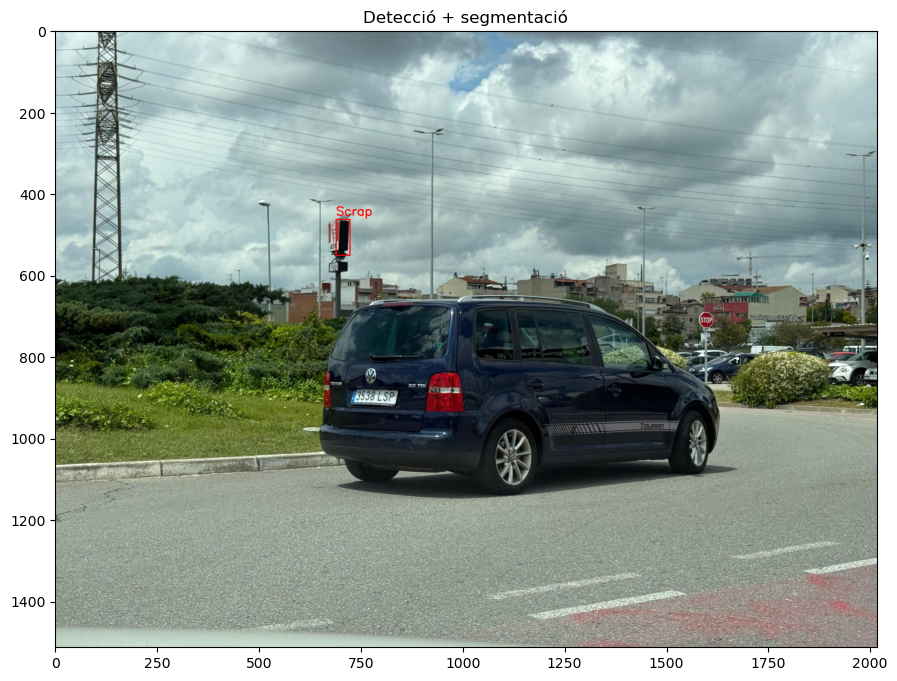

In [23]:
# Imatge a tractar
frame = cv2.imread("foto1.jpg")

# Detecció
results = model_det(frame)[0]

# Llista de noms de classe del model de classificació
class_names = ["Scrap", "Verd", "Ignorar", "Vermell", "Groc"]

for box in results.boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    
    if cls == 0:  # semàfor
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        x1, y1 = max(x1, 0), max(y1, 0)
        x2, y2 = min(x2, frame.shape[1]), min(y2, frame.shape[0])

        roi = frame[y1:y2, x1:x2]

        # Classificació amb EfficientNet
        img_pil = Image.fromarray(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
        input_tensor = transform(img_pil).unsqueeze(0)

        with torch.no_grad():
            output = model_sem(input_tensor)
            pred = torch.argmax(output, dim=1).item()
            classe = class_names[pred]

        # Mostra resultat
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(frame, classe, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

# Correcció BGR a RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# 📺 Mostra la imatge
plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb)
plt.title("Detecció + segmentació")
plt.show()
#print(f"Partes detectades: {[model_sem.names[int(c)] for c in results_seg.boxes.cls]}")


0: 480x640 4 traffic lights, 51.5ms
Speed: 14.8ms preprocess, 51.5ms inference, 3.4ms postprocess per image at shape (1, 3, 480, 640)


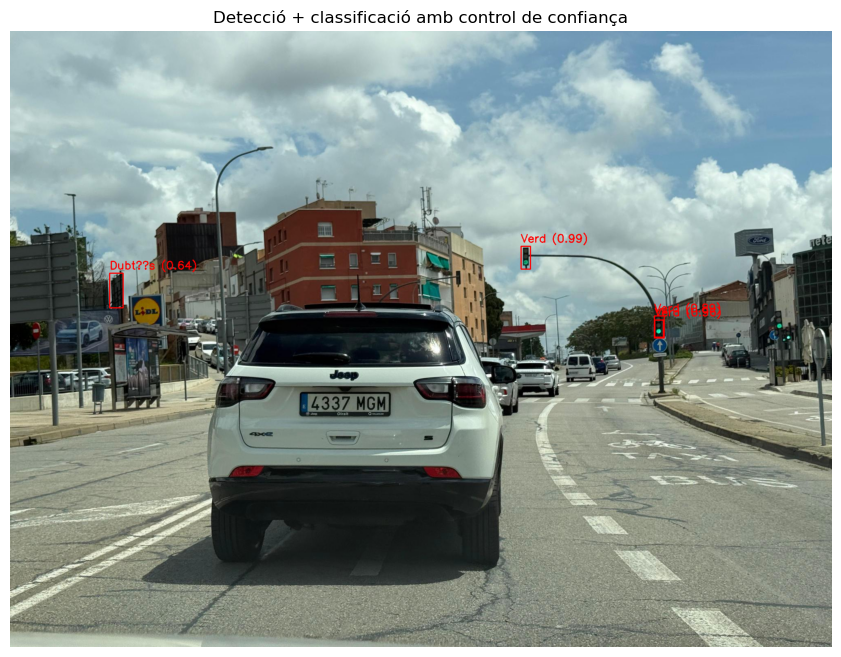

In [4]:
from collections import Counter
import torch.nn.functional as F

# Imatge a tractar
frame = cv2.imread("3.jpg")

# Detecció
results = model_det(frame)[0]

# Noms de classes
class_names = ["Scrap", "Verd", "Ignorar", "Vermell", "Groc"]

for box in results.boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    
    if cls == 0:  # semàfor
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        x1, y1 = max(x1, 0), max(y1, 0)
        x2, y2 = min(x2, frame.shape[1]), min(y2, frame.shape[0])

        roi = frame[y1:y2, x1:x2]

        # Classificació amb EfficientNet
        img_pil = Image.fromarray(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
        input_tensor = transform(img_pil).unsqueeze(0)

        with torch.no_grad():
            output = model_sem(input_tensor)
            probs = F.softmax(output, dim=1)
            confidence, pred = torch.max(probs, dim=1)
            confidence = confidence.item()
            pred = pred.item()

        # Aplica llindar de confiança
        if confidence > 0.7:
            classe = class_names[pred]
        else:
            classe = "Dubtós"

        # Mostra resultat
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(frame, f"{classe} ({confidence:.2f})", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

# Correcció BGR a RGB per mostrar amb matplotlib
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# 📺 Mostra la imatge
plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb)
plt.title("Detecció + classificació amb control de confiança")
plt.axis("off")
plt.show()



0: 480x640 7 cars, 3 motorcycles, 18.3ms
Speed: 3.6ms preprocess, 18.3ms inference, 3.1ms postprocess per image at shape (1, 3, 480, 640)
Vehicle: car | Alçada bbox: 39.88% | Centre X: 39.73%
4
Vehicle: car | Alçada bbox: 6.15% | Centre X: 62.30%
Vehicle: car | Alçada bbox: 4.30% | Centre X: 7.74%
Vehicle: motorcycle | Alçada bbox: 31.28% | Centre X: 95.44%
Vehicle: motorcycle | Alçada bbox: 25.99% | Centre X: 91.82%
Vehicle: car | Alçada bbox: 3.64% | Centre X: 17.04%
Vehicle: car | Alçada bbox: 3.64% | Centre X: 20.88%
Vehicle: motorcycle | Alçada bbox: 18.92% | Centre X: 91.20%
Vehicle: car | Alçada bbox: 3.77% | Centre X: 59.13%
Vehicle: car | Alçada bbox: 3.31% | Centre X: 56.52%


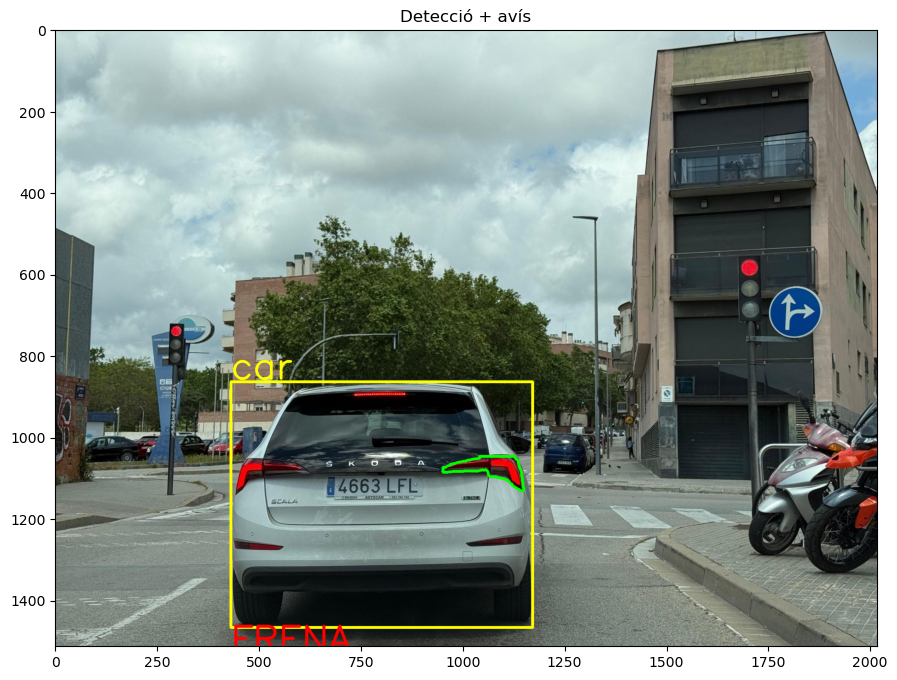

In [51]:
# 📦 Carrega els dos models
model_det = YOLO("Models/Detectvehicles.pt")   # Model que detecta Símbols
# Carrega model complet
model_sem = torch.load("Models/TrafficLight.pt", map_location="cpu")
model_seg = YOLO("Models/CarSegment.pt")  # Model que segmenta cotxes
model_bra = torch.load("Models/DetectBrake2.pt", map_location="cuda")
model_sem.eval()
model_bra = model_bra.cuda()
model_bra.eval()

# 🔄 Transformació per al model class
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 🔄 Transformació per al model binari
transform2 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Imatge a tractar
frame = cv2.imread("Media/P8.jpg")

# Detecció
results_det = model_det(frame)[0]

# Per detecció mostra per pantalla
for box in results_det.boxes:

    cls = int(box.cls[0])
    label = model_det.names[cls]
    conf = box.conf[0]
    
    # Coordenades
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    x1, y1 = max(x1, 0), max(y1, 0)
    x2, y2 = min(x2, frame.shape[1]), min(y2, frame.shape[0])

    # Perill de col·lisió - TERÇ CENTRAL X i alçada bbox > 22%
    width = frame.shape[1]
    height = frame.shape[0]

    center_x = (x1 + x2) / 2
    bbox_height = y2 - y1

    left_third = width / 3
    right_third = 2 * width / 3

    percent_height = (bbox_height / height) * 100
    percent_center_x = (center_x / width) * 100

    print(f"Vehicle: {label} | Alçada bbox: {percent_height:.2f}% | Centre X: {percent_center_x:.2f}%")

    # Comprovació de perill
    perill = left_third <= center_x <= right_third and bbox_height > 0.22 * height

    if perill:
        cv2.putText(frame, "", (50, 100), #"PELIGRO  DE COLISION"
            cv2.FONT_HERSHEY_SIMPLEX, 4, (0, 0, 255), 10)


    # Color de la bbox
    color = (0, 255, 255) if perill else (0, 254, 255)  # Vermell si perill, sinó groc

    if perill:
        # Dibuix bbox i text
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 5)
        label_text = f"{label}"
        cv2.putText(frame, label_text, (x1, y1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 3, color, 5)
    '''

    if left_third <= center_x <= right_third and bbox_height > 0.22 * height:
        print("Perill de col·lisió")
        cv2.putText(frame, "Perill de col·lisió", (50, 100),
            cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 4)


# bbox + text
    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 255), 5)
    label_text = f"{label} {conf:.2f}"
    cv2.putText(frame, label_text, (x1, y1 - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 255), 5)

    
'''
    # Segmentació
    roi = frame[y1:y2, x1:x2] # ROI = Region of interest anomenat a la segmentació, regió de la imatge
    results_seg = model_seg(roi, conf=0.45, iou=0.7, verbose=False)[0]

    if results_seg.masks is not None and perill: # Si segmenta, es mostren els resultats
        for i, mask in enumerate(results_seg.masks.data):
            if i == 4 or i == 7 or i == 5:
                mask_np = mask.cpu().numpy().astype("uint8") * 255
                mask_resized = cv2.resize(mask_np, (x2 - x1, y2 - y1))
                
                print(i)
                
                # Contorn
                contours, _ = cv2.findContours(mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                cv2.drawContours(roi, contours, -1, (0, 255, 0), 5) # Verd

                # Nom
                #part_label = model_seg.names[int(results_seg.boxes.cls[i])]
                #M = cv2.moments(mask_resized)
                #cX = int(M["m10"] / M["m00"])
                #cY = int(M["m01"] / M["m00"])
                #cv2.putText(roi, part_label, (cX - 10, cY), 
                            #cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 0), 10, cv2.LINE_AA) 
                
                # Retalla part segmentada
                seg_img = roi.copy()
                seg_img[mask_resized == 0] = 0

                # Prepara per inferència
                input_img = cv2.cvtColor(seg_img, cv2.COLOR_BGR2RGB)
                input_img = cv2.resize(input_img, (224, 224))
                input_tensor = transform2(input_img).unsqueeze(0).cuda()

                with torch.no_grad():
                    output = model_bra(input_tensor)
                    prob = torch.sigmoid(output).item()
                    frenada = prob > 0.5

                # Mostra resultat
                status_text = "FRENA" if frenada else "NO FRENA"
                color = (0, 0, 255) if frenada else (0, 255, 255)
                cv2.putText(frame, status_text, (x1, y2 + 60),
                            cv2.FONT_HERSHEY_SIMPLEX, 3, color, 6, cv2.LINE_AA)
                            

# Correcció BGR a RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# 📺 Mostra la imatge
plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb)
plt.title("Detecció + avís")
plt.show()


0: 480x640 3 traffic lights, 54.6ms
Speed: 6.2ms preprocess, 54.6ms inference, 5.3ms postprocess per image at shape (1, 3, 480, 640)


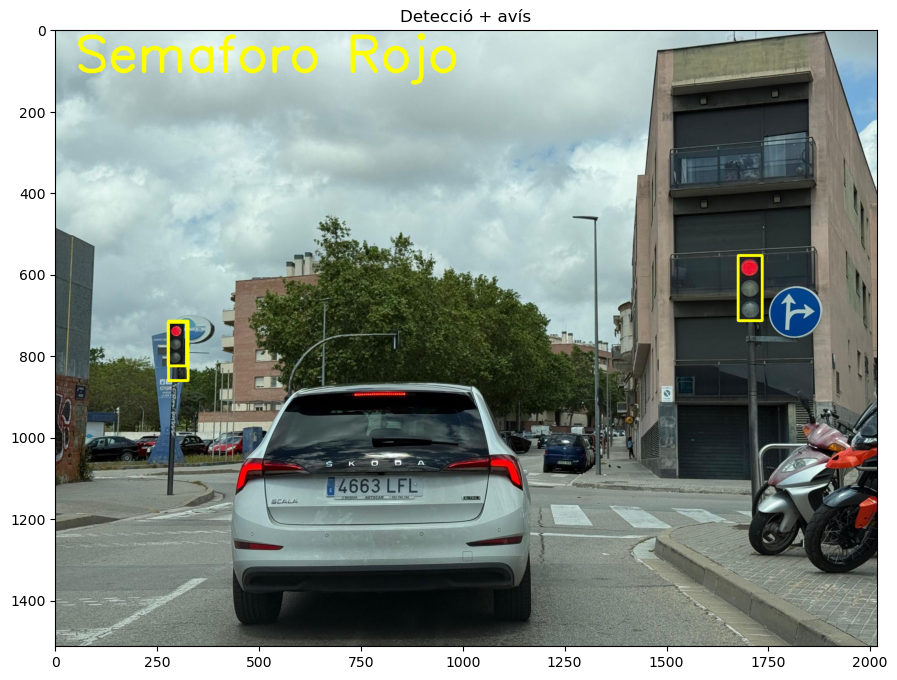

In [61]:
# STOPS

# 📦 Carrega els dos models
model_det = YOLO("Models/Detectvehicles.pt")   # Model que detecta Símbols
# Carrega model complet
model_sem = torch.load("Models/TrafficLight.pt", map_location="cuda")
model_seg = YOLO("Models/CarSegment.pt")  # Model que segmenta cotxes
model_bra = torch.load("Models/DetectBrake2.pt", map_location="cuda")
model_dts = YOLO("Models/Detect_Signs.pt")
model_sem.eval()
model_bra = model_bra.cuda()
model_bra.eval()

# 🔄 Transformació per al model class
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 🔄 Transformació per al model binari
transform2 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Imatge a tractar
frame = cv2.imread("Media/P8.jpg")

# Detecció
results_det = model_dts(frame)[0]

# Per detecció mostra per pantalla
for box in results_det.boxes:

    cls = int(box.cls[0])
    label = model_dts.names[cls]
    conf = box.conf[0]
    
    # Coordenades
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    x1, y1 = max(x1, 0), max(y1, 0)
    x2, y2 = min(x2, frame.shape[1]), min(y2, frame.shape[0])

    


    


# bbox + text
    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 255), 5)
    label_text = f"{label}"
    #cv2.putText(frame, label_text, (x1, y1 - 8),
                #cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 255), 5)

    
    if label_text == 'stop sign':
        cv2.putText(frame, "STOP visible", (50, 100), #"PELIGRO  DE COLISION"
            cv2.FONT_HERSHEY_SIMPLEX, 4, (0, 255, 255), 10)
                            
cv2.putText(frame, "Semaforo Rojo", (50, 100), #"PELIGRO  DE COLISION"
            cv2.FONT_HERSHEY_SIMPLEX, 4, (0, 255, 255), 10)
# Correcció BGR a RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# 📺 Mostra la imatge
plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb)
plt.title("Detecció + avís")
plt.show()

In [2]:
from ultralytics import YOLO
import cv2

# 📦 Carrega els dos models
model_det = YOLO("Models/Detectvehicles.pt")   # Model que detecta cotxes i motos
model_seg = YOLO("Models/CarSegment.pt")  # Model que segmenta cotxes

# 🎥 Llegeix el vídeo
video_path = "Media/v1.mp4"
cap = cv2.VideoCapture(video_path)

# 📽️ Paràmetres del vídeo de sortida
out = cv2.VideoWriter("V1.mp4",
                      cv2.VideoWriter_fourcc(*'mp4v'),
                      cap.get(cv2.CAP_PROP_FPS),
                      (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))

# Processa cada frame
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # DETECCIÓ de vehicles
    results_det = model_det(frame)[0]
    deteccions = results_det.boxes

    for box in deteccions:
        cls = int(box.cls[0])
        label = model_det.names[cls]

        # Coordenades del bounding box
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        x1, y1 = max(x1, 0), max(y1, 0)
        x2, y2 = min(x2, frame.shape[1]), min(y2, frame.shape[0])

        # Aplica segmentació amb el model, independentment de la classe
        roi = frame[y1:y2, x1:x2]
        results_seg = model_seg(roi, verbose=False)[0]

        if results_seg.masks is not None:
            for mask in results_seg.masks.data:
                mask_np = mask.cpu().numpy().astype("uint8") * 255
                mask_resized = cv2.resize(mask_np, (x2 - x1, y2 - y1))
                if label == "car":
                    colored_mask = cv2.applyColorMap(mask_resized, cv2.COLORMAP_JET)
                else:
                    colored_mask = cv2.applyColorMap(mask_resized, cv2.COLORMAP_OCEAN)
                roi_overlay = cv2.addWeighted(roi, 0.6, colored_mask, 0.4, 0)
                frame[y1:y2, x1:x2] = roi_overlay

        # Dibuixa bounding box i etiqueta per TOTS els objectes
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Guarda el frame processat
    out.write(frame)

# Allibera recursos
cap.release()
out.release()
cv2.destroyAllWindows()


0: 384x640 2 cars, 118.6ms
Speed: 13.6ms preprocess, 118.6ms inference, 424.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 14.6ms
Speed: 3.2ms preprocess, 14.6ms inference, 3.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 15.3ms
Speed: 2.8ms preprocess, 15.3ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 15.2ms
Speed: 2.9ms preprocess, 15.2ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 14.9ms
Speed: 3.3ms preprocess, 14.9ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 14.9ms
Speed: 2.9ms preprocess, 14.9ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 15.1ms
Speed: 2.8ms preprocess, 15.1ms inference, 3.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 18.1ms
Speed: 3.5ms preprocess, 18.1ms inference, 3.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x64

error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'


In [2]:
# 🎥 Llegeix el vídeo
video_path = "Media/V1.mp4"
cap = cv2.VideoCapture(video_path)

# 📽️ Sortida
out = cv2.VideoWriter("V1Sem.mp4",
                      cv2.VideoWriter_fourcc(*'mp4v'),
                      cap.get(cv2.CAP_PROP_FPS),
                      (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))

# 🔁 Per cada frame
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Detecció
    results = model_det(frame)[0]

    # Llista de noms de classe del model de classificació
    class_names = ["Scrap", "Verd", "Ignorar", "Vermell", "Groc"]

    for box in results.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
    
        if cls == 0:  # semàfor
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            x1, y1 = max(x1, 0), max(y1, 0)
            x2, y2 = min(x2, frame.shape[1]), min(y2, frame.shape[0])

            roi = frame[y1:y2, x1:x2]

            # Classificació amb EfficientNet
            img_pil = Image.fromarray(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
            input_tensor = transform(img_pil).unsqueeze(0)

            with torch.no_grad():
                output = model_sem(input_tensor)
                pred = torch.argmax(output, dim=1).item()
                classe = class_names[pred]

            # Mostra resultat
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)
            cv2.putText(frame, classe, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        
    # Escriu el frame al vídeo sortida
    out.write(frame)

# 🔚 Allibera
cap.release()
out.release()
cv2.destroyAllWindows()


'''# Correcció BGR a RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# 📺 Mostra la imatge
plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb)
plt.title("Detecció + segmentació")
plt.show()
#print(f"Partes detectades: {[model_sem.names[int(c)] for c in results_seg.boxes.cls]}")'''


0: 384x640 1 traffic light, 94.7ms
Speed: 4.5ms preprocess, 94.7ms inference, 123.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 traffic light, 20.7ms
Speed: 4.5ms preprocess, 20.7ms inference, 3.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 traffic light, 17.2ms
Speed: 2.7ms preprocess, 17.2ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 traffic lights, 16.3ms
Speed: 2.8ms preprocess, 16.3ms inference, 3.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 traffic light, 15.9ms
Speed: 3.8ms preprocess, 15.9ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 traffic light, 17.0ms
Speed: 3.8ms preprocess, 17.0ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 traffic light, 28.0ms
Speed: 3.2ms preprocess, 28.0ms inference, 3.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 20.3ms
Speed: 3.6ms preprocess, 20.3m

error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'
